# MicroLive: Example for Transcription Analysis.

___
This notebook demonstrates how to use MicroLive programmatically for processing transcription analysis. 

The aim of the the example is to show how to use MicroLive to detect the transcription site in a time-lapse microscopy dataset.

The used dataset is obtained from the following publication: <br>
Forero-Quintero, L.S., Raymond, W., Handa, T., Saxton, M.N., Morisaki, T., Kimura, H., Bertrand, E., Munsky, B. and Stasevich, T.J., 2021. Live-cell imaging reveals the spatiotemporal organization of endogenous RNA polymerase II phosphorylation at a single gene. Nature Communications, 12(1), p.3158. https://doi.org/10.1038/s41467-021-23417-0

----

This repository contains fluorescent images is accesible at: https://doi.org/10.6084/m9.figshare.14187011

----

### Imaging Setup and Parameters
| Parameter | Value | Description |
| :--- | :--- | :--- |
| **Microscope** | Custom Widefield | Highly inclined illumination (HILO) |
| **Objective** | 60×, NA 1.48 | Oil immersion (Olympus) |
| **Excitation Lasers** | 488, 561, 637 nm | Solid-state lasers (Vortran) |
| **Field of View (FOV)** | 66.6 × 66.6 µm² | 512 × 512 pixels |
| **Pixel Size (nm)** | 130 nm | pixel size in XY plane |
| **Z-Stacks** | 13 planes | 0.5 µm (500 nm) spacing |
| **Time Interval** | 60 s | Interval between scans |
| **Total Duration** | 35 min | Total imaging time |

### Channel Assignments
| Channel | Target | Fluorophore | Laser (nm) |
| :--- | :--- | :--- | :--- |
| **0** | CTD-RNAP2 | CF640 | 637 |
| **1** | Ser5ph-RNAP2 | Cy3 | 561 |
| **2** | mRNA | GFP | 488 |

-----

The selected image is a 2D (maximum projection) dataset with 35 frames. <br>
Fig1c_BG_MAX_Cell02_ExemplaryCell.tif 

# Implementation Overview:

----
- Import libraries and configure paths
- Load microscopy images (TIFF or LIF)
- Nucleus segmentation (Cellpose)
- Clusters and spots detection to detect transcription sites.
- Quantification of the transcription sites in nucleus 

-----

### Load modules
----

In [1]:
"""
MicroLive Notebook
==================
This notebook requires MicroLive to be installed:
    pip install microlive

For development mode:
    pip install -e /path/to/microlive
"""
# MicroLive imports
from microlive import microscopy as mi
from microlive.utils.device import check_gpu_status

# Verify GPU support
check_gpu_status()

# Standard scientific imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


MicroLive loaded from: /Users/nzlab-la/Desktop/microlive


In [2]:
# Load the image
tif_image_path = Path("/Users/nzlab-la/Desktop/microlive/notebooks/examples/revision_data/Forero_2021/Fig1c_BG_MAX_Cell02_ExemplaryCell.tif")
raw_image = tifffile.imread(str(tif_image_path))
print(f"Loaded TIFF with shape: {raw_image.shape}") # [T,C, Y, X]

Loaded TIFF with shape: (35, 3, 512, 512)


In [3]:
# Set the axis order that matches YOUR file
input_axis_order = ['T', 'C', 'Y', 'X']  
# Convert to MicroLive's standard format [T, Z, Y, X, C]
converter = mi.ConvertFormat(
    image=raw_image,
    original_order=input_axis_order,
    desired_order=['T', 'Z', 'Y', 'X', 'C']
)
image_stack = converter.convert()
print(f"Converted to MicroLive format [T, Z, Y, X, C]: {image_stack.shape}") # the converted added a T dimension with a single time point.

Converted to MicroLive format [T, Z, Y, X, C]: (35, 1, 512, 512, 3)


### Define Image Metadata
-----

In [4]:
# Physical parameters (adjust to your microscope settings)
pixel_size_xy_nm = 130  # Pixel size in nanometers (XY)
voxel_size_z_nm = 500   # Voxel size in nanometers (Z) - Single z-frame. 
time_interval_sec = 60  # Time between frames in seconds - This image contains a single timepoint.

# For MicroLive classes
list_voxels = [voxel_size_z_nm, pixel_size_xy_nm]  # [Z, YX]

# Extract dimensions from the correctly formatted image
n_timepoints = image_stack.shape[0]
n_zslices = image_stack.shape[1]
height_y = image_stack.shape[2]
width_x = image_stack.shape[3]
n_channels = image_stack.shape[4]

print(f"Image dimensions (TZYXC format):")
print(f"  Time points (T): {n_timepoints}")
print(f"  Z-slices (Z): {n_zslices}")
print(f"  Height (Y): {height_y} px")
print(f"  Width (X): {width_x} px")
print(f"  Channels (C): {n_channels}")
print(f"\nPhysical scale:")
print(f"  Pixel size: {pixel_size_xy_nm} nm")
print(f"  Z-step: {voxel_size_z_nm} nm")
print(f"  Frame interval: {time_interval_sec} sec")

Image dimensions (TZYXC format):
  Time points (T): 35
  Z-slices (Z): 1
  Height (Y): 512 px
  Width (X): 512 px
  Channels (C): 3

Physical scale:
  Pixel size: 130 nm
  Z-step: 500 nm
  Frame interval: 60 sec


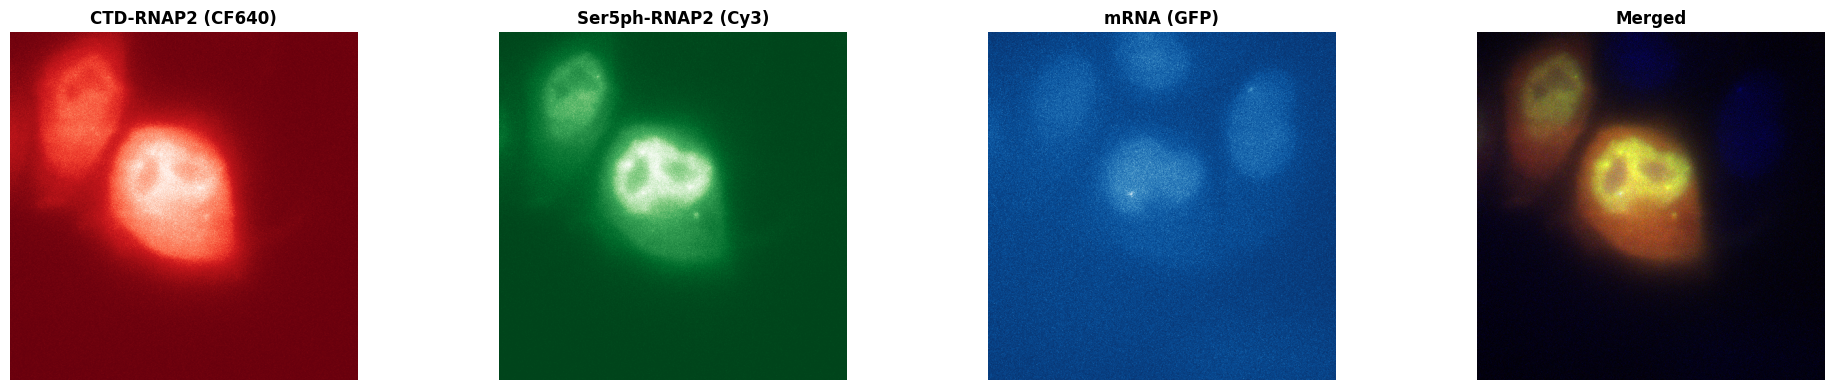

In [ ]:
# Visualizing the image: all color channels for the first timepoint and the merged image
img_slice = image_stack[0, 0, :, :, :]  # Assuming image shape is [T, Z, Y, X, C]
# Channel names and colormaps
colormaps = ['Reds_r', 'Greens_r', 'Blues_r']
channel_names = [ 'CTD-RNAP2 (CF640)', 'Ser5ph-RNAP2 (Cy3)', 'mRNA (GFP)' , 'Merged']

vmax_values = [
    np.percentile(img_slice[:, :, 0], 99.95),  # Channel 0 (DAPI)
    np.percentile(img_slice[:, :, 1], 99.95),  # Channel 1 (GFP)
    np.percentile(img_slice[:, :, 2], 100),  # Channel 2 (Cytosol)
]

# Create figure with 5 columns
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i in range(3):
    ax = axes[i]
    ax.imshow(img_slice[:, :, i], cmap=colormaps[i], vmin=0, vmax=vmax_values[i])
    ax.set_title(channel_names[i], fontsize=12, fontweight='bold')
    ax.axis('off')
merged = np.zeros((*img_slice.shape[:2], 3), dtype=np.float32)
merged[:, :, 0] = img_slice[:, :, 0] / vmax_values[0]  
merged[:, :, 1] = img_slice[:, :, 1] / vmax_values[1]  
merged[:, :, 2] = img_slice[:, :, 2] / vmax_values[2]  
merged = np.clip(merged, 0, 1)
axes[3].imshow(merged)
axes[3].set_title(channel_names[3], fontsize=12, fontweight='bold')
axes[3].axis('off')
plt.tight_layout()
plt.show()

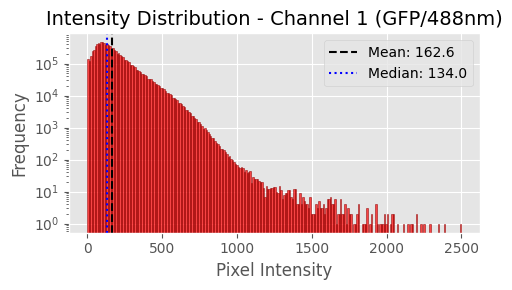

Min: 0, Max: 2499, Mean: 162.56


In [6]:
# Visualize the intensity distribution of the channel with spots
selected_channel_data = image_stack[...,2].flatten()
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(selected_channel_data, bins=256, range=(0, selected_channel_data.max()), 
        color='red', alpha=0.7, edgecolor='darkred', linewidth=0.5)
ax.set_xlabel('Pixel Intensity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Intensity Distribution - Channel 1 (GFP/488nm)', fontsize=14)
ax.set_yscale('log')  
ax.axvline(np.mean(selected_channel_data), color='black', linestyle='--', label=f'Mean: {np.mean(selected_channel_data):.1f}')
ax.axvline(np.median(selected_channel_data), color='blue', linestyle=':', label=f'Median: {np.median(selected_channel_data):.1f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Min: {selected_channel_data.min()}, Max: {selected_channel_data.max()}, Mean: {np.mean(selected_channel_data):.2f}")

### Perform nuclei segmentation using cellpoose
___

In [7]:
#  Nucleus Segmentation (using nuclei model)
nucleus_channel = 0
diameter_nucleus = 100
img_slice = image_stack[0, 0, :, :, :]  # image shape is [T, Z, Y, X, C] -> [ Y, X, C]

print("Running nucleus segmentation...")
segmenter_nuc = mi.CellSegmentation(
    img_slice,
    channels_cytosol=None,  # Only nucleus
    channels_nucleus=[nucleus_channel],
    diameter_nucleus=diameter_nucleus,
    model_nuc_segmentation='nuclei',  # Default model for nucleus
    selection_metric=None,
    running_in_pipeline=True,
    show_plot=False
)
_, mask_nucleus, _ = segmenter_nuc.calculate_masks()
print(f"Nucleus: {np.max(mask_nucleus) if mask_nucleus is not None else 0} nuclei detected")


Running nucleus segmentation...
Nucleus: 2 nuclei detected


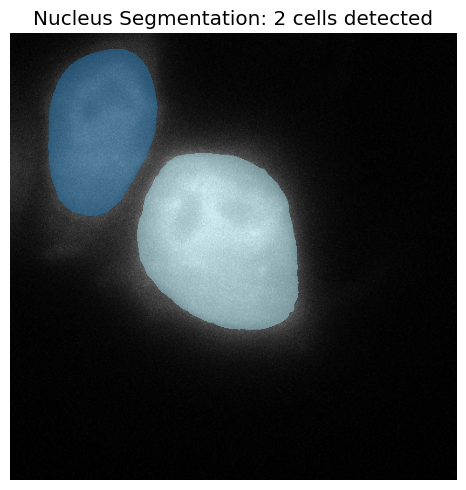

In [8]:
# Plot results
fig, ax = plt.subplots(figsize=(5, 5))
max_proj_cyto = img_slice[:, :, nucleus_channel]
vmax = np.percentile(max_proj_cyto,99.9)
vmin = np.percentile(max_proj_cyto, 1.0)
ax.imshow(max_proj_cyto, cmap='gray', vmin=vmin, vmax=vmax)
if mask_nucleus is not None and np.max(mask_nucleus) > 0:
    cytosol_overlay = np.ma.masked_where(mask_nucleus == 0, mask_nucleus)
    ax.imshow(cytosol_overlay, cmap='tab20', alpha=0.5)
ax.set_title(f'Nucleus Segmentation: {np.max(mask_nucleus) if mask_nucleus is not None else 0} cells detected')
ax.axis('off')
plt.tight_layout()
plt.show()

### 2D Spot Detection with Pre-computed Masks
____

In [15]:
# Tracking parameters
tracking_params = {
    'channels_spots': [2],           # Channel to detect spots in
    'channels_cytosol': [None],         # Cytosol channel for background
    'channels_nucleus': [2],      # Nucleus channel (None if not applicable)
    'threshold_for_spot_detection': 40,  # Detection threshold
    'yx_spot_size_in_px': 7,         # Expected spot size in pixels
    'z_spot_size_in_px': 1,          # Spot size in Z
    'cluster_radius_nm': 500,        # Cluster detection radius
    'min_length_trajectory': 30,     # Minimum trajectory length (frames)
    'maximum_range_search_pixels': 10,  # Max displacement between frames
    'memory': 0,                     # Frames to remember for linking
    'link_using_3d_coordinates': False,
    'use_maximum_projection': True,
}


# Run particle tracking
tracker = mi.ParticleTracking(
    image=image_stack,
    list_voxels=list_voxels,
    masks_nuclei=mask_nucleus,
    step_size_in_sec=time_interval_sec,
    **tracking_params
)

# Get tracking results
list_dataframes, _ = tracker.run()
df_tracking = list_dataframes[0] if list_dataframes else pd.DataFrame()
print(f"\nTracking Results:")
print(f"  Total spots detected: {len(df_tracking)}")
print(f"  Unique trajectories: {df_tracking['particle'].nunique() if 'particle' in df_tracking.columns else 0}")

if not df_tracking.empty:
    display(df_tracking.head())

[ParticleTracking._normalize_mask_to_tyx] Input mask shape: (1, 512, 512), ndim: 3, T=35
[ParticleTracking] Expanding single-frame 3D mask (1, 512, 512) to TYX [35, 512, 512]
[ParticleTracking._normalize_mask_to_tyx] Input mask shape: (512, 512), ndim: 2, T=35
[ParticleTracking] Expanding YX mask (512, 512) to TYX [35, 512, 512] (static mask across all frames)

Tracking Results:
  Total spots detected: 35
  Unique trajectories: 1


,image_id,cell_id,nuc_loc_y,nuc_loc_x,cyto_loc_y,cyto_loc_x,nuc_area_px,cyto_area_px,cell_area_px,z,...,snr_ch_2,total_spot_int_ch_0,total_spot_int_ch_1,total_spot_int_ch_2,spot_size_ch_0,spot_size_ch_1,spot_size_ch_2,frame,time,particle
0,0,0,238,240,0,0,30014,0,0,0.0,...,1.1985,159293.0,284545.0,41710.0,4.4657,4.2705,4.1037,0,0,0
1,0,0,238,240,0,0,30014,0,0,0.0,...,1.2502,157074.0,281865.0,39055.0,4.5589,4.2794,4.3908,1,60,0
2,0,0,238,240,0,0,30014,0,0,0.0,...,1.6012,158488.0,286560.0,42189.0,4.6665,4.4464,4.2505,2,120,0
3,0,0,238,240,0,0,30014,0,0,0.0,...,1.2940,165089.0,284391.0,43678.0,4.4984,4.6110,4.1063,3,180,0
4,0,0,238,240,0,0,30014,0,0,0.0,...,2.2354,160741.0,278829.0,45690.0,4.7483,4.4047,4.0397,4,240,0


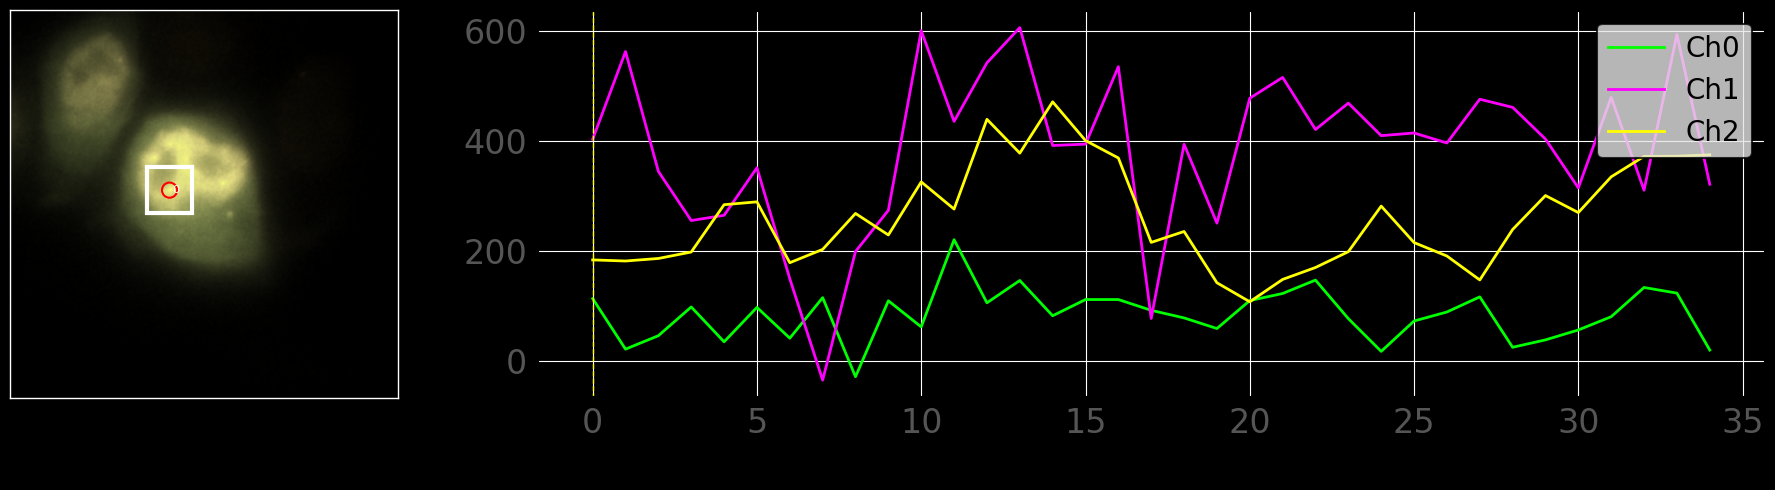

In [16]:
plotter = mi.Plots()
_ = plotter.plot_cell_zoom_with_timecourse(
    image_TZYXC=image_stack,
    df=df_tracking,
    selected_spot=0,
    time_point=0,
    spot_mark_size=10,      # Increase for larger circles
    spot_color='red',      # Change color if white is hard to see
    min_percentile=20,
    list_max_percentile=[99.5, 99., 100],
    figsize=(18,5), 
)

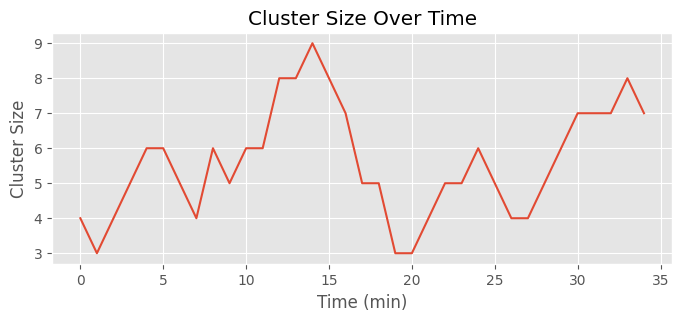

In [22]:
# print the cluster size over time
particle_id = 0
# print time vs cluster size
plt.figure(figsize=(8, 3))
plt.plot(df_tracking[df_tracking['particle'] == particle_id]['frame'], df_tracking[df_tracking['particle'] == particle_id]['cluster_size'])
plt.xlabel('Time (min)')
plt.ylabel('Cluster Size')
plt.title('Cluster Size Over Time')
plt.show()  